In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\pawar\Downloads\data-export (1) (1).csv")
df

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
...,...,...,...,...,...,...,...,...,...,...
3178,Unassigned,2024042806,0,1,0,0,0,2,0,2
3179,Unassigned,2024043005,0,1,0,0,0,2,0,2
3180,Unassigned,2024043006,0,1,0,0,0,2,0,2
3181,Unassigned,2024050105,0,1,0,0,0,2,0,2


In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [5]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ["Channel group", "DateHour", "Users", "Session", "Engaged Sessions", "Average engagement time per session","Engaged sessions per user","Events per session",	"Engagement rate",	"Event count"]

In [6]:
df.head()

,Channel group,DateHour,Users,Session,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Session                              3182 non-null   object
 4   Engaged Sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [8]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format="%Y%m%d%H", errors = 'coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   object        
 3   Session                              3182 non-null   object        
 4   Engaged Sessions                     3182 non-null   object        
 5   Average engagement time per session  3182 non-null   object        
 6   Engaged sessions per user            3182 non-null   object        
 7   Events per session                   3182 non-null   object        
 8   Engagement rate                      3182 non-null   object        
 9   Event count                          3182 non-null   object        
dtypes: datetime6

In [14]:
numeric_cols = df.columns.drop(["Channel group", "DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df["DateHour"] = pd.to_datetime(df["DateHour"], errors='coerce')
df["Hour"] = df["DateHour"].dt.hour

df.head()


,Channel group,DateHour,Users,Session,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [15]:
df.describe()

,DateHour,Users,Session,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# sessions and user over time

In [16]:
sns.set(style = "whitegrid")

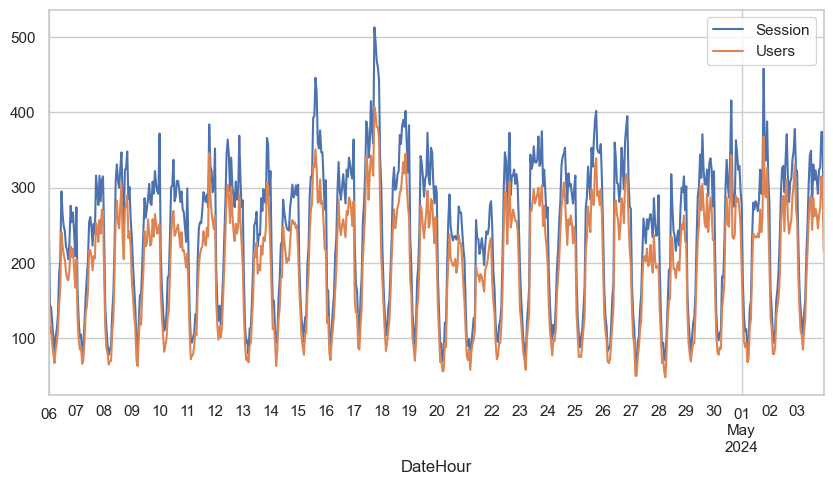

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Session", "Users"]].sum().plot(ax=plt.gca())
plt.show()


# Total Users by channel

C:\Users\pawar\AppData\Local\Temp\ipykernel_13500\3269510407.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_users, x="Channel group", y="Users", palette="viridis")


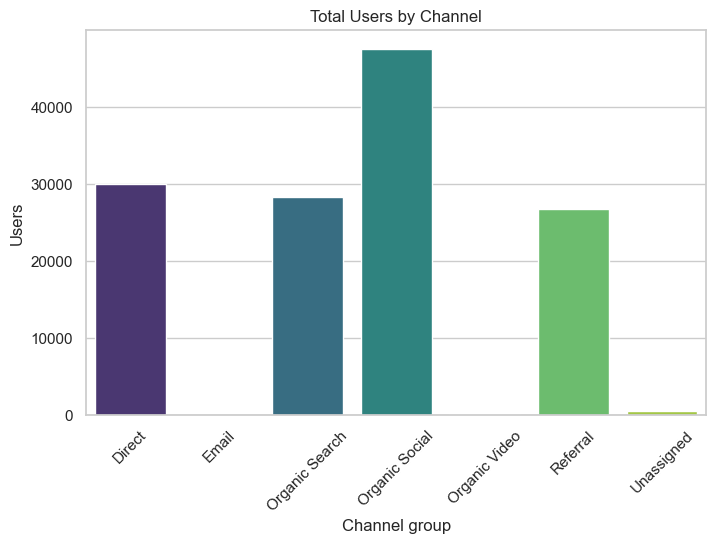

In [20]:
channel_users = df.groupby("Channel group")["Users"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=channel_users, x="Channel group", y="Users", palette="viridis")
plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()


# Average engagement time by channel

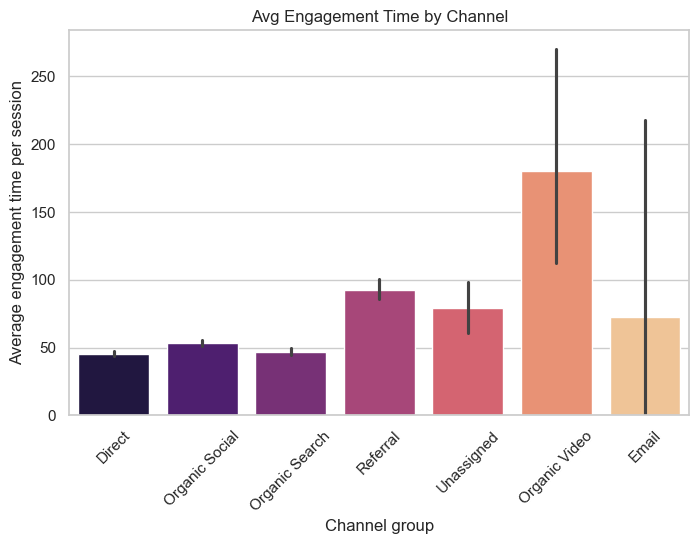

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Channel group",
    y="Average engagement time per session",
    estimator=np.mean,
    hue="Channel group",
    palette="magma",
    legend=False
)
plt.title("Avg Engagement Time by Channel")
plt.xticks(rotation=45)
plt.show()


# Engagement Rate Distribution by channel

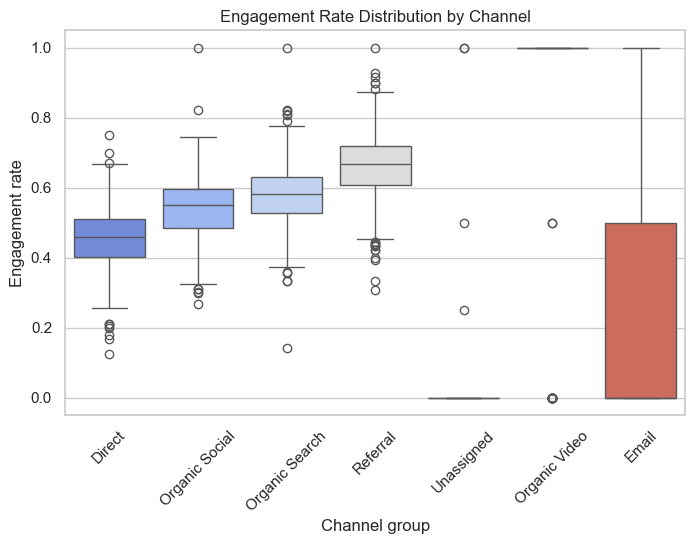

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Channel group",
    y="Engagement rate",
    palette="coolwarm",
    hue="Channel group",
    legend=False
)
plt.title("Engagement Rate Distribution by Channel")
plt.xticks(rotation=45)
plt.show()


In [34]:
print(df.columns.tolist())


['Channel group', 'DateHour', 'Users', 'Session', 'Engaged Sessions', 'Average engagement time per session', 'Engaged sessions per user', 'Events per session', 'Engagement rate', 'Event count', 'Hour']


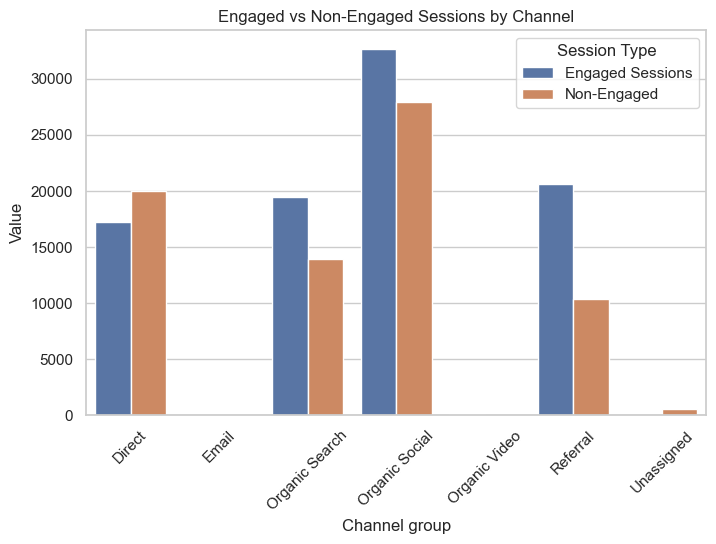

In [35]:
# Grouping sessions by Channel group
session_df = df.groupby("Channel group")[["Session", "Engaged Sessions"]].sum().reset_index()

# Creating a Non-Engaged column correctly
session_df["Non-Engaged"] = session_df["Session"] - session_df["Engaged Sessions"]

# Melting for visualization
session_df_melted = session_df.melt(
    id_vars="Channel group",
    value_vars=["Engaged Sessions", "Non-Engaged"],
    var_name="Session Type",
    value_name="Value"
)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted, x="Channel group", y="Value", hue="Session Type")
plt.title("Engaged vs Non-Engaged Sessions by Channel")
plt.xticks(rotation=45)
plt.show()


# traffic by hour and channel

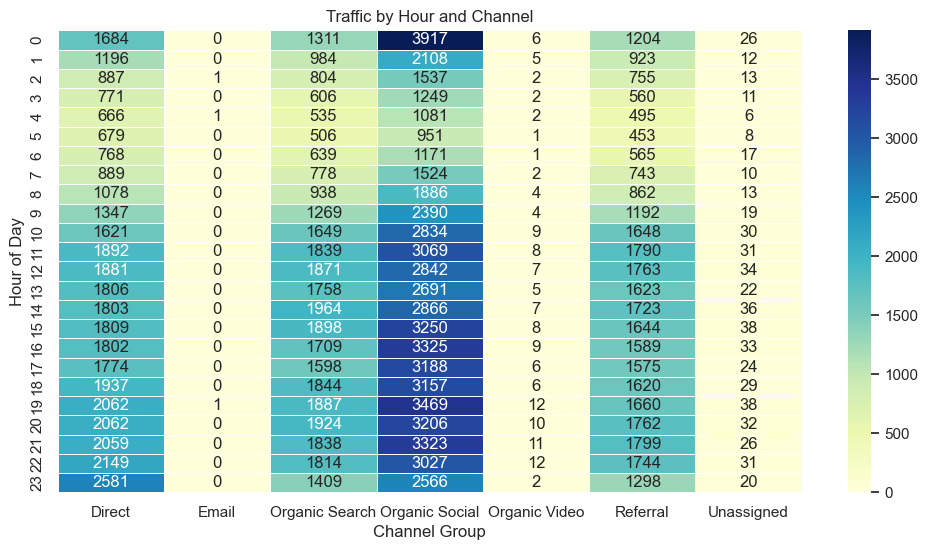

In [37]:
# Create heatmap data
heatmap_data = df.groupby(["Hour", "Channel group"])["Session"].sum().unstack().fillna(0)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt='.0f'
)

plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")
plt.show()


In [39]:
# Grouping by DateHour and calculating mean
df_plot = df.groupby("DateHour")[["engagement rate", "Session"]].mean().reset_index()

# Plotting
plt.figure(figsize=(10,5))
plt.plot(df_plot["DateHour"], df_plot["engagement rate"], label="Engagement Rate", color="green")
plt.xlabel("DateHour")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate over Time")
plt.xticks(rotation=45)
plt.legend()
plt.show()


KeyError: "Columns not found: 'engagement rate'"

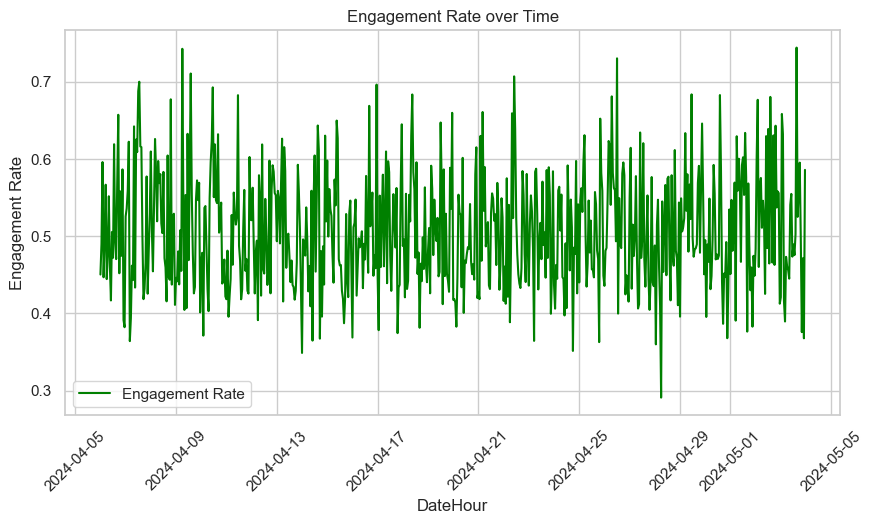

In [40]:
# Grouping by DateHour and calculating mean
df_plot = df.groupby("DateHour")[["Engagement rate", "Session"]].mean().reset_index()

# Plotting Engagement Rate over time
plt.figure(figsize=(10,5))
plt.plot(df_plot["DateHour"], df_plot["Engagement rate"], label="Engagement Rate", color="green")
plt.xlabel("DateHour")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate over Time")
plt.xticks(rotation=45)
plt.legend()
plt.show()
